In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Exercise - 1: Image Processing with Pillow and Matplotlib

Task 1: Read and display the image


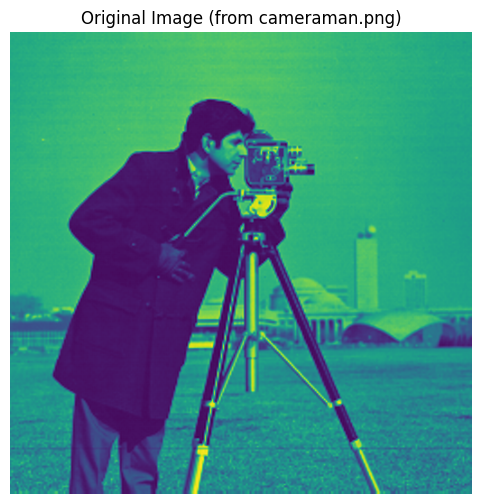

Image shape: (512, 512), Data type: uint8
Image is grayscale. Converting to 3-channel RGB for channel separation task.


In [6]:
# Import necessary libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define the image path
image_path = '/content/drive/MyDrive/cameraman.png'

# Task 1: Read and display the image
print("Task 1: Read and display the image")

# Read the image using Pillow
img_pil = Image.open(image_path)

# Display using Matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(img_pil)
plt.title('Original Image (from cameraman.png)')
plt.axis('off')
plt.show()

# Convert to NumPy array for further processing
img_np = np.array(img_pil)
print(f"Image shape: {img_np.shape}, Data type: {img_np.dtype}")

# If the image is grayscale, we might need to convert it to RGB for channel separation later.
# Check if it's grayscale (2D array)
if len(img_np.shape) == 2:
    print("Image is grayscale. Converting to 3-channel RGB for channel separation task.")
    img_rgb = Image.fromarray(img_np).convert('RGB')
    img_np_rgb = np.array(img_rgb)
else:
    img_np_rgb = img_np.copy()


Task 2: Display top-left 100x100 pixels


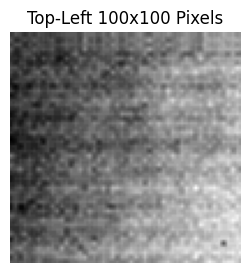

In [7]:
# Task 2: Display only the top left corner of 100x100 pixels
print("\nTask 2: Display top-left 100x100 pixels")

# Extract the top-left 100x100 pixels using NumPy array indexing
top_left_corner = img_np[:100, :100]

plt.figure(figsize=(3, 3))
plt.imshow(top_left_corner, cmap='gray') # Use cmap='gray' for grayscale images
plt.title('Top-Left 100x100 Pixels')
plt.axis('off')
plt.show()


Task 3: Display R, G, B channels


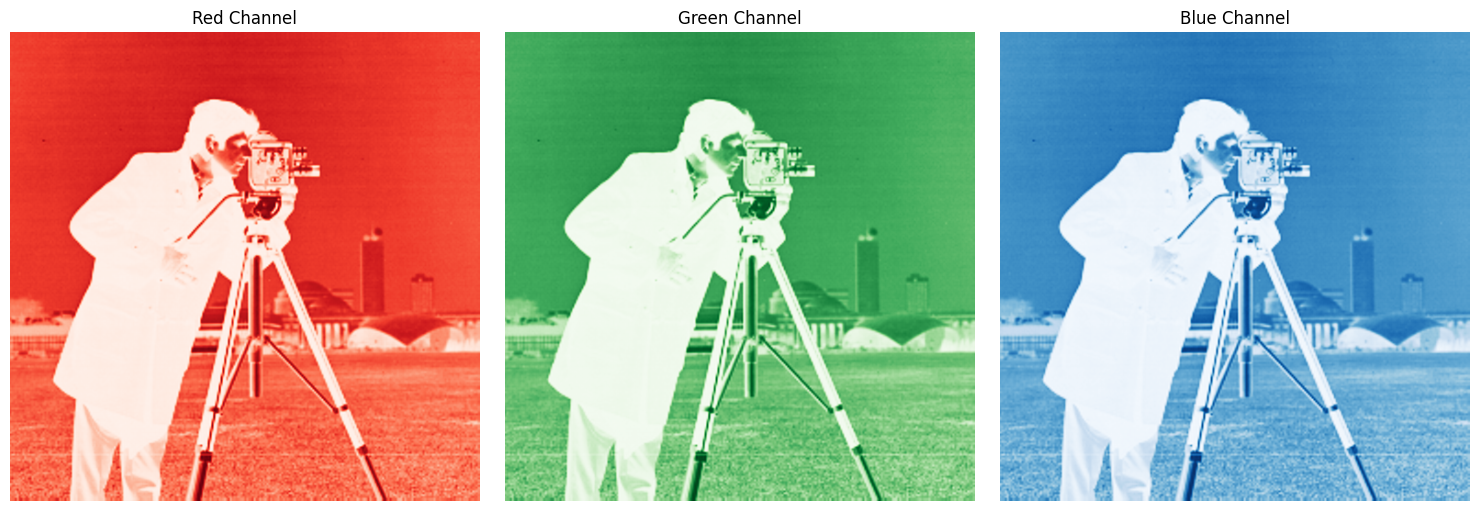

Note: The visible red, green, and blue backgrounds are due to the 'cmap' argument in matplotlib, highlighting each channel's intensity within its respective color. If displaying with Pillow directly, they would appear grayscale.


In [8]:
# Task 3: Show the three color channels (R, G, B)
print("\nTask 3: Display R, G, B channels")

# Ensure we have a 3-channel image for this task
# If the original image was grayscale, img_np_rgb was created in Task 1.
if len(img_np_rgb.shape) < 3 or img_np_rgb.shape[2] != 3:
    print("Converting image to RGB for channel separation.")
    # If it's still not 3 channels (e.g., RGBA or 1 channel), explicitly convert to RGB
    img_pil_rgb = Image.fromarray(img_np_rgb).convert('RGB')
    img_np_rgb = np.array(img_pil_rgb)

# Separate channels
red_channel = img_np_rgb[:, :, 0]
green_channel = img_np_rgb[:, :, 1]
blue_channel = img_np_rgb[:, :, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(red_channel, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(green_channel, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blue_channel, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Note: The visible red, green, and blue backgrounds are due to the 'cmap' argument in matplotlib, highlighting each channel's intensity within its respective color. If displaying with Pillow directly, they would appear grayscale.")


Task 4: Modify top-left 100x100 pixels


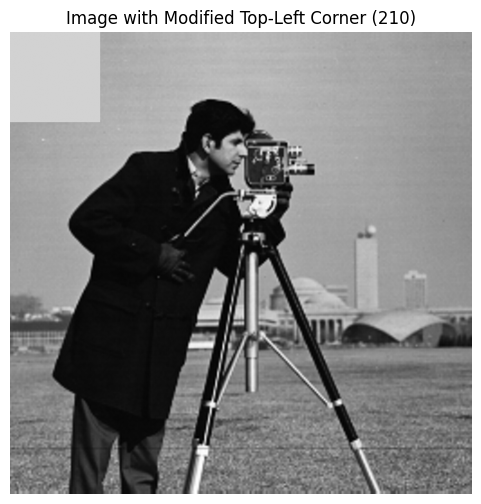

In [9]:
# Task 4: Modify the top 100 x 100 pixels to a value of 210 and display the resulting image
print("\nTask 4: Modify top-left 100x100 pixels")

# Create a copy to avoid modifying the original image array directly
modified_img_np = img_np.copy()

# Modify the pixel values of the top-left 100x100 region
# For grayscale, assign a single value
# For color, assign to all channels if it's an RGB image
if len(modified_img_np.shape) == 2: # Grayscale
    modified_img_np[:100, :100] = 210
elif modified_img_np.shape[2] == 3: # RGB
    modified_img_np[:100, :100, :] = 210
else:
    print("Warning: Image format not directly supported for modification (e.g., RGBA). Modifying first 3 channels if present.")
    modified_img_np[:100, :100, :3] = 210

plt.figure(figsize=(6, 6))
plt.imshow(modified_img_np, cmap='gray') # Use cmap='gray' if the base image was grayscale
plt.title('Image with Modified Top-Left Corner (210)')
plt.axis('off')
plt.show()

### Exercise - 2: Grayscale Image Processing and Transformation


Task 1: Load and display a grayscale image


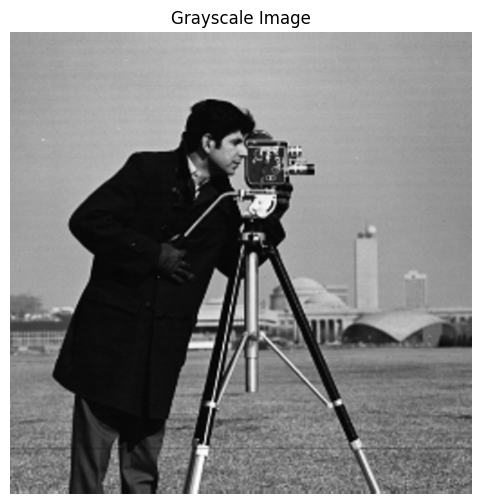

Grayscale image shape: (512, 512), Data type: uint8


In [10]:
# Task 1: Load and display a grayscale image
print("\nTask 1: Load and display a grayscale image")

# Define the image path (reusing the cameraman for consistency, converting to grayscale)
# For this task, we will explicitly load it as grayscale or convert if it's color
image_path_grayscale = '/content/drive/MyDrive/cameraman.png'

# Load the image using Pillow and convert to 'L' (8-bit pixels, black and white)
img_pil_gray = Image.open(image_path_grayscale).convert('L')
img_np_gray = np.array(img_pil_gray)

plt.figure(figsize=(6, 6))
plt.imshow(img_np_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()
print(f"Grayscale image shape: {img_np_gray.shape}, Data type: {img_np_gray.dtype}")


Task 2: Extract and display the middle section (150x150 pixels)


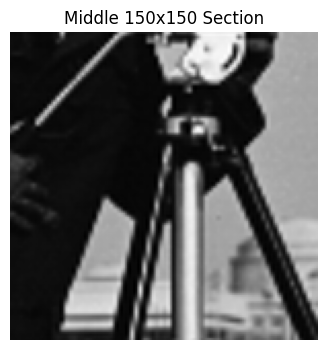

Middle section shape: (150, 150)


In [11]:
# Task 2: Extract and display the middle section of the image (150 pixels)
print("\nTask 2: Extract and display the middle section (150x150 pixels)")

h, w = img_np_gray.shape

# Calculate the starting and ending indices for a 150x150 middle section
# Ensure the section is not larger than the image dimensions
section_size = 150

start_h = max(0, (h - section_size) // 2)
end_h = min(h, start_h + section_size)

start_w = max(0, (w - section_size) // 2)
end_w = min(w, start_w + section_size)

middle_section = img_np_gray[start_h:end_h, start_w:end_w]

plt.figure(figsize=(4, 4))
plt.imshow(middle_section, cmap='gray')
plt.title(f'Middle {section_size}x{section_size} Section')
plt.axis('off')
plt.show()
print(f"Middle section shape: {middle_section.shape}")


Task 3: Apply a simple threshold


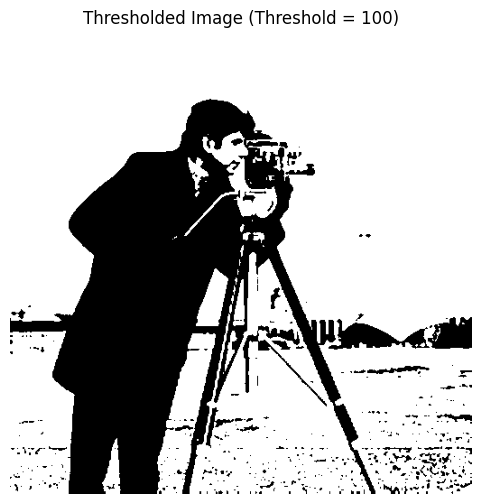

In [12]:
# Task 3: Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0)
print("\nTask 3: Apply a simple threshold")

threshold_value = 100
binary_img_np = np.zeros_like(img_np_gray)
binary_img_np[img_np_gray >= threshold_value] = 255

plt.figure(figsize=(6, 6))
plt.imshow(binary_img_np, cmap='gray')
plt.title(f'Thresholded Image (Threshold = {threshold_value})')
plt.axis('off')
plt.show()


Task 4: Rotate the image 90 degrees clockwise


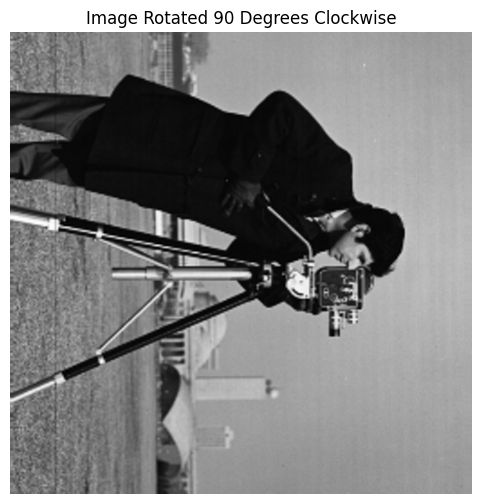

In [13]:
# Task 4: Rotate the image 90 degrees clockwise and display the result
print("\nTask 4: Rotate the image 90 degrees clockwise")

# Convert NumPy array back to Pillow Image for rotation
img_pil_gray_for_rotation = Image.fromarray(img_np_gray)
rotated_img_pil = img_pil_gray_for_rotation.rotate(-90, expand=True) # -90 for clockwise
rotated_img_np = np.array(rotated_img_pil)

plt.figure(figsize=(6, 6))
plt.imshow(rotated_img_np, cmap='gray')
plt.title('Image Rotated 90 Degrees Clockwise')
plt.axis('off')
plt.show()


Task 5: Convert grayscale to RGB


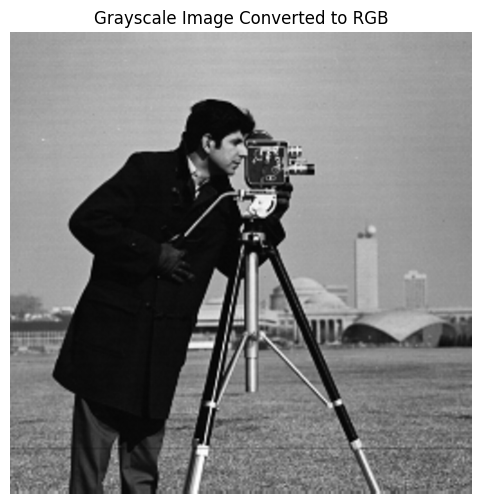

Converted RGB image shape: (512, 512, 3), Data type: uint8


In [14]:
# Task 5: Convert the grayscale image to an RGB image
print("\nTask 5: Convert grayscale to RGB")

# Grayscale image (img_np_gray) has shape (H, W)
# To convert to RGB, we stack the grayscale channel three times
img_rgb_from_gray_np = np.stack([img_np_gray, img_np_gray, img_np_gray], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb_from_gray_np)
plt.title('Grayscale Image Converted to RGB')
plt.axis('off')
plt.show()
print(f"Converted RGB image shape: {img_rgb_from_gray_np.shape}, Data type: {img_rgb_from_gray_np.dtype}")

### Exercise - 3: Image Compression and Decompression using PCA


Task 1: Load and Prepare Data for PCA
Original image shape: (512, 512), Data type: float64
Centered data shape: (512, 512)
Covariance matrix shape: (512, 512)

Task 2: Eigen Decomposition and Identifying Principal Components
Eigenvalues shape: (512,)
Eigenvectors shape: (512, 512)
Top 5 Eigenvalues: [628073.69333443 264907.26821051 103581.57943132  75185.90733793
  46328.31857672]


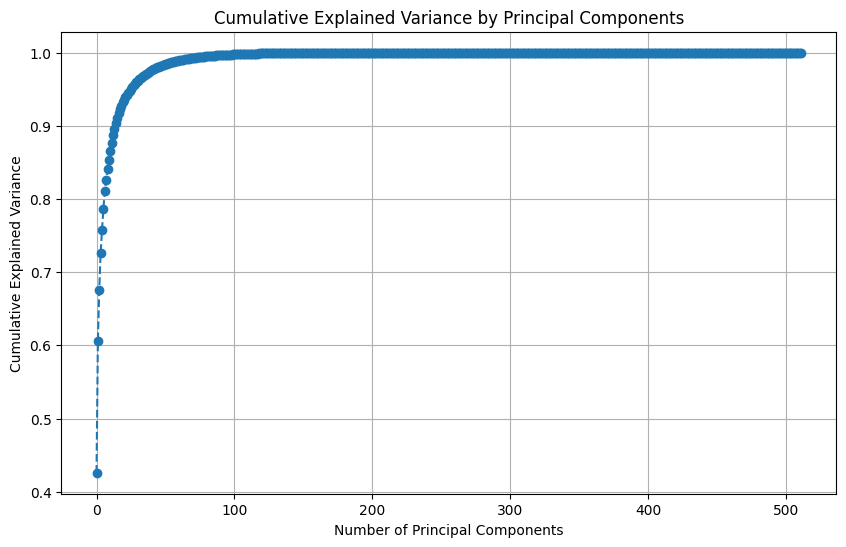

Explained variance ratio for first 5 components: [0.4259071  0.17963798 0.07024037 0.0509848  0.03141599]
Cumulative explained variance for first 5 components: [0.4259071  0.60554508 0.67578545 0.72677025 0.75818624]
Number of components to explain 95% variance: 26


In [28]:
# Import necessary libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
print("\nTask 1: Load and Prepare Data for PCA")

# Fetch an image of your choice (using cameraman.png)
image_path_pca = '/content/drive/MyDrive/cameraman.png'
img_pil_pca = Image.open(image_path_pca).convert('L') # Convert to grayscale
img_np_pca = np.array(img_pil_pca, dtype=np.float64)

print(f"Original image shape: {img_np_pca.shape}, Data type: {img_np_pca.dtype}")

# Reshape the 2D image (Height x Width) into a 1D vector (Height * Width) for PCA
# Or, for image compression, we typically treat rows/columns as features/samples.
# Let's consider each row of the image as a sample and pixels in that row as features.
# Or, we can flatten the image into a single vector and then apply PCA.
# For image compression, it's more common to apply PCA either on rows or on columns.
# Let's apply PCA on the rows of the image. Each row is a sample, columns are features.
# So, the data matrix X will have shape (H, W).

X = img_np_pca.copy()

# Center the dataset - Standardize the Data
mean_vec = np.mean(X, axis=0) # Mean of each column (feature)
X_centered = X - mean_vec

print(f"Centered data shape: {X_centered.shape}")

# Calculate the covariance matrix of the Standardized data
# Covariance matrix C = (X_centered.T @ X_centered) / (n_samples - 1)
cov_matrix = np.cov(X_centered, rowvar=False) # rowvar=False means columns are variables

print(f"Covariance matrix shape: {cov_matrix.shape}")

# 2. Eigen Decomposition and Identifying Principal Components
print("\nTask 2: Eigen Decomposition and Identifying Principal Components")

# Compute Eigenvalues and Eigenvectors
# Note: np.linalg.eig returns eigenvalues and eigenvectors.
# For a symmetric matrix like a covariance matrix, np.linalg.eigh is more stable.
# Since cov_matrix is square and symmetric, eigh is appropriate.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print(f"Eigenvalues shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")

# Sort the eigenvalues in descending order and choose the top k eigenvectors
# Get the indices that would sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices] # Sort eigenvectors according to eigenvalues

print("Top 5 Eigenvalues:", sorted_eigenvalues[:5])

# Identify the Principal Components with the help of a cumulative Sum plot.
# Calculate the explained variance ratio
total_eigenvalues = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_eigenvalues
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Display the explained variance ratio for a few components to give an idea
print("Explained variance ratio for first 5 components:", explained_variance_ratio[:5])
print("Cumulative explained variance for first 5 components:", cumulative_explained_variance[:5])

# You would typically choose k based on a threshold (e.g., 95% or 99% explained variance)
# For example, find k for 95% explained variance
k_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {k_95}")

# Select the top k eigenvectors (Principal Components)
# For now, let's keep all for initial reconstruction or pick a sensible k later
# For demonstration, we might pick k_95 for compression


Task 3: Reconstruction and Experiment


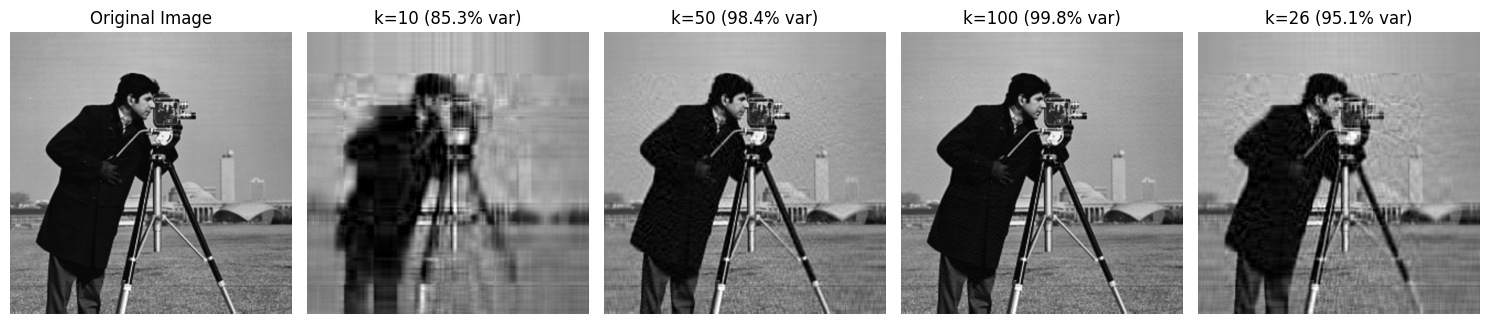

Reconstruction complete for various principal components. Observe the quality improvement with increasing k.


In [25]:
# 3. Reconstruction and Experiment
print("\nTask 3: Reconstruction and Experiment")

# Ensure sorted_eigenvectors, X_centered, mean_vec are available from previous step (Task 1 & 2)
# If running this cell independently, you might need to re-run Task 1 and 2 cells.

# Select different numbers of principal components (k)
k_values = [10, 50, 100, k_95] # Using k_95 calculated in Task 2

plt.figure(figsize=(15, 5))

# Original image display
plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(img_np_pca, cmap='gray')
plt.title('Original Image')
plt.axis('off')

for i, k in enumerate(k_values):
    # Select the top k eigenvectors (Principal Components)
    components = sorted_eigenvectors[:, :k]

    # Project the centered data onto the principal components
    # This creates the lower-dimensional representation
    projected_data = np.dot(X_centered, components)

    # Reconstruct the image from the projected data
    # reconstructed_centered = projected_data @ components.T
    # Add back the mean to get the actual pixel values
    reconstructed_img = np.dot(projected_data, components.T) + mean_vec

    # Clip values to be within valid image range [0, 255] and convert to uint8
    reconstructed_img = np.clip(reconstructed_img, 0, 255).astype(np.uint8)

    # Display the reconstructed image
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(reconstructed_img, cmap='gray')
    # Find the explained variance for the current k
    explained_var_k = cumulative_explained_variance[k-1] * 100
    plt.title(f'k={k} ({explained_var_k:.1f}% var)')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Reconstruction complete for various principal components. Observe the quality improvement with increasing k.")